(example_found_biases_in_metrics_by_site)=

# Discover biases in metrics by site.
`uniharmony` allows you to stratify the performance metrics by site, unraveling hidden patterns. In this example, we will not simulate site effects.

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.metrics import report_metric_by_site


sns.set_theme(style="whitegrid")
verbosity("error")
clf = LogisticRegression()

### Let's create the first Scenario: a dataset with 3 good sites and 1 bad site (signal strength = 0) to show the effect of having a bad site in the dataset

In [2]:
n_bad_sites = 1
X_bad, y_bad, sites_bad = make_multisite_classification(n_sites=n_bad_sites, signal_strength=0, site_effect_strength=0)

# Used to simulate "good" sites
signal_strength = 1
X_good, y_good, sites_good = make_multisite_classification(n_sites=3, signal_strength=signal_strength, site_effect_strength=0)
# Increase site labels for good sites to avoid overlap with bad sites
sites_good = sites_good + n_bad_sites

X = np.concatenate([X_bad, X_good], axis=0)
y = np.concatenate([y_bad, y_good], axis=0)
sites = np.concatenate([sites_bad, sites_good], axis=0)

X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(X, y, sites)

clf.fit(X_train, y_train)
y_pred_s1 = clf.predict(X_test)
metric_s1 = report_metric_by_site(y_test, y_pred_s1, sites_test, balanced_accuracy_score, overall_performance=True)
print(f"Overall bACC for Scenario 1: {metric_s1['overall']:.3}")

Overall bACC for Scenario 1: 0.726


### Now let's create a second Scenario: a dataset with 3 bad sites and 1 good site (signal strength = 1)

In [3]:
n_bad_sites = 3
X_bad, y_bad, sites_bad = make_multisite_classification(n_sites=n_bad_sites, signal_strength=0, site_effect_strength=0)

# Used to simulate "good" sites
signal_strength = 1
X_good, y_good, sites_good = make_multisite_classification(n_sites=1, signal_strength=signal_strength, site_effect_strength=0)
# Increase site labels for good sites to avoid overlap with bad sites
sites_good = sites_good + n_bad_sites

X = np.concatenate([X_bad, X_good], axis=0)
y = np.concatenate([y_bad, y_good], axis=0)
sites = np.concatenate([sites_bad, sites_good], axis=0)

X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(X, y, sites)

clf.fit(X_train, y_train)
y_pred_s2 = clf.predict(X_test)
metric_s2 = report_metric_by_site(y_test, y_pred_s2, sites_test, balanced_accuracy_score, overall_performance=True)
print(f"Overall bACC for Scenario 2: {metric_s2['overall']:.3}")

Overall bACC for Scenario 2: 0.7


# Let's plot the results obtained in the each site

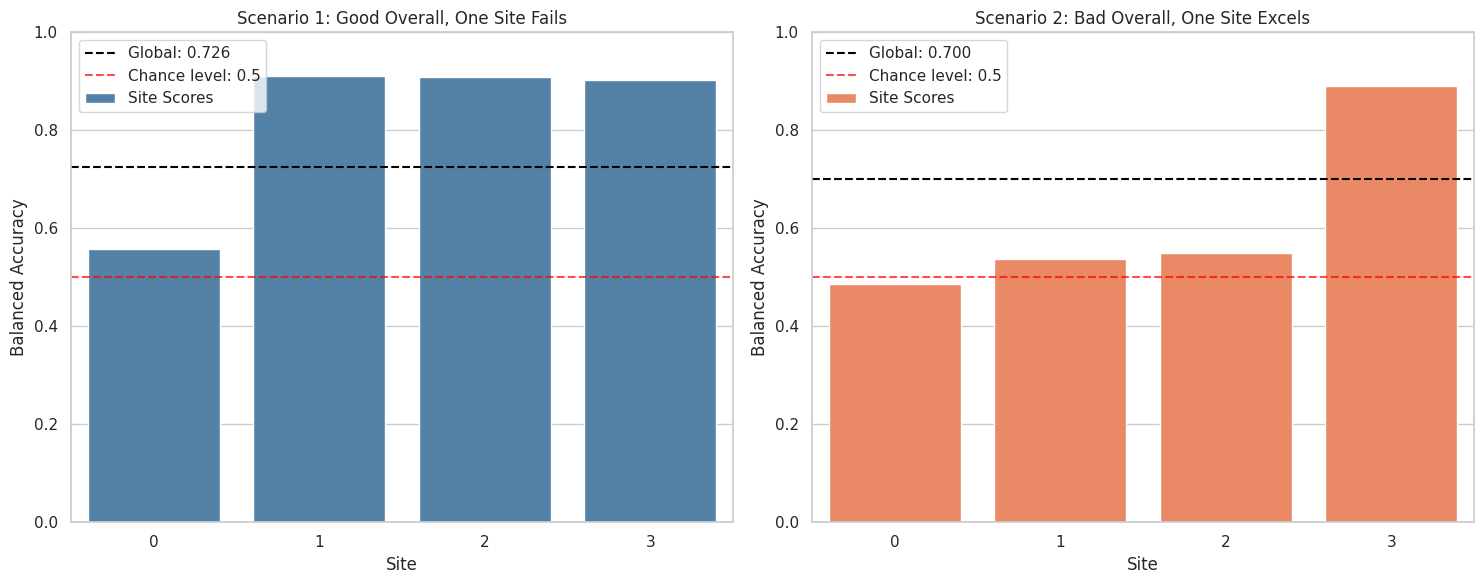

In [4]:
sites_unique = np.unique(sites)
# Extract global performance for both scenarios
metric_global_s1 = metric_s1.pop("overall")
metric_global_s2 = metric_s2.pop("overall")

# Visualize both scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

######### Scenario 1
site_scores_s1 = [metric_s1[s] for s in sites_unique]

sns.barplot(x=sites_unique, y=site_scores_s1, color="steelblue", label="Site Scores", ax=axes[0])
axes[0].axhline(
    metric_global_s1,
    color="black",
    linestyle="--",
    label=f"Global: {metric_global_s1:.3f}",
)
axes[0].axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Chance level: 0.5",
)
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Scenario 1: Good Overall, One Site Fails")
axes[0].legend()
axes[0].grid(True, alpha=1, axis="y")
axes[0].set_ylim([0, 1])


############# Scenario 2
site_scores_s2 = [metric_s2[s] for s in sites_unique]
sns.barplot(x=sites_unique, y=site_scores_s2, color="coral", label="Site Scores", ax=axes[1])
axes[1].axhline(
    metric_global_s2,
    color="black",
    linestyle="--",
    label=f"Global: {metric_global_s2:.3f}",
)
axes[1].axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Chance level: 0.5",
)
axes[1].set_xlabel("Site")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Scenario 2: Bad Overall, One Site Excels")
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### But, how is it possible that they have an similar overall performance? Where is the catch? The sites have different number of samples!

### In the first Scenario, even when the first site is bigger, the other 3 compensates the bad performance.
### In the second Scenario, the last site (good one) is bigger an pushes the overall performance up.

### If we had only reported the overall performance, we would not be able to unravel the site's behavior.
